# Brent Oil Price Change Point Analysis

## Exploratory Data Analysis (EDA)

### Week 10 Challenge

**Author:** E. Frida N.

---

### Project Objective

This notebook performs the initial exploratory analysis of historical Brent crude oil prices. The objective is to understand long-term trends, volatility patterns, and statistical properties of the data before applying Bayesian Change Point Analysis. The insights generated in this notebook provide the foundation for identifying structural breaks and associating them with major geopolitical and economic events.


In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15,6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
import sys
print(sys.executable)

c:\Users\nfepo\Downloads\10 Academy\W10\brent-oil-change-point-analysis\venv\Scripts\python.exe


In [9]:
from statsmodels.tsa.stattools import adfuller

In [10]:
# Load the Brent oil price dataset
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [11]:
import pandas as pd

print(pd.__version__)

3.0.3


In [12]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15,6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [14]:
# ============================================================
# Dataset Overview
# ============================================================

print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("Data Types")
print("="*50)
print(df.dtypes)

print("\n")

print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

print("\n")

print("="*50)
print("Summary Statistics")
print("="*50)
print(df.describe())

Dataset Shape
(9011, 2)


Data Types
Date         str
Price    float64
dtype: object


Missing Values
Date     0
Price    0
dtype: int64


Summary Statistics
             Price
count  9011.000000
mean     48.420782
std      32.860110
min       9.100000
25%      19.050000
50%      38.570000
75%      70.090000
max     143.950000


In [15]:
# ============================================================
# Convert Date Column
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [16]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%y"
)

In [17]:
# ============================================================
# Set Date Index
# ============================================================

df.set_index("Date", inplace=True)

df.head()

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


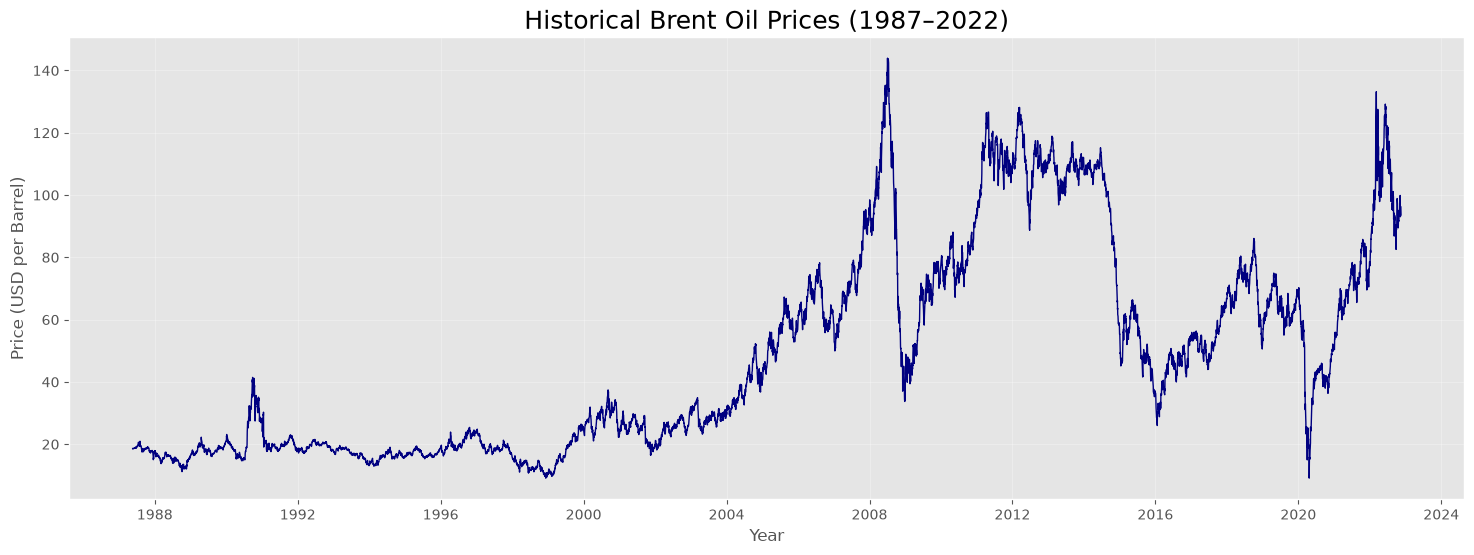

In [18]:
# ============================================================
# Brent Oil Prices
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(df.index,
         df["Price"],
         color="navy",
         linewidth=1)

plt.title("Historical Brent Oil Prices (1987–2022)",
          fontsize=18)

plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.grid(alpha=0.3)

plt.show()

## Time Series Exploration

Before applying Bayesian Change Point Detection, it is important to understand the statistical characteristics of the Brent oil price series. This section explores the overall trend, rolling statistics, distribution of prices, and daily price changes to identify patterns that may influence model selection.